# Notebook 03 — Event-Conditioned Reliability Analysis
**Thesis Chapter 7** | **Input:** `data/2_events.csv` | **Output:** `data/3_results.csv`

---

## Purpose — three research questions

| RQ | Question | Section |
|----|---------|---------|
| RQ1 | What does reconstruction reveal about campaign-wide reliability? | §7.1 — global PDR, rolling time series, burst distribution |
| RQ2 | How does reliability vary across environmental and operational events? | §7.3–7.6 — event-conditioned PDR for all 10 events |
| RQ3 | Which conditions are most strongly associated with loss risk? | §7.7 — logistic regression, odds ratios |

## Filtered dataset
All event-conditioned analysis uses `df_link` — outage intervals excluded:
```python
df_link = df[~df['is_outage']].copy()
```
This ensures PDR variation reflects radio-channel conditions, not infrastructure downtime.


## 0 · Imports & Load

In [1]:
import pandas as pd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

DATA_DIR = Path('../data')
df = pd.read_csv(DATA_DIR / '2_events.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

# filtered dataset — outage intervals excluded only
df_link = df[~df['is_outage']].copy().reset_index(drop=True)

print(f'Full dataset : {len(df):,} rows')
print(f'df_link      : {len(df_link):,} rows')
print(f'Excluded     : {len(df) - len(df_link):,} rows (outages)')
print(f'Devices      : {sorted(df_link["device_id"].unique())}')
print(f'Campaign     : {df["time"].min().date()} → {df["time"].max().date()}')


Full dataset : 2,634,930 rows
df_link      : 2,634,764 rows
Excluded     : 166 rows (outages)
Devices      : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Campaign     : 2024-10-01 → 2025-09-30


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10, 'axes.titlesize': 11,
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})
C = {'blue': '#0077BB', 'orange': '#EE7733', 'green': '#009988',
     'red': '#CC3311', 'purple': '#AA3377', 'navy': '#004488', 'grey': '#BBBBBB',
     'brown': '#882255', 'teal': '#44AA99', 'yellow': '#DDCC77'}
DEVICE_COLORS = [C['blue'], C['orange'], C['green'], C['red'], C['purple'], C['navy']]
TOA_MS = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6, 11: 987.1, 12: 1810.4}
FIG_DIR = Path('../figures');
FIG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name):
    fig.savefig(FIG_DIR / f'{name}.pdf')
    fig.savefig(FIG_DIR / f'{name}.png')
    print(f'  Saved: figures/{name}')
    plt.show()


def pdr_grp(grp):
    rx = len(grp)
    lost = int(grp['tx_loss'].sum())
    return rx / (rx + lost) * 100 if (rx + lost) > 0 else 0


def burst_rate_grp(grp):
    return (grp['tx_loss'] >= 3).mean() * 100


print('Style ready.')


Style ready.


## 1 · Statistical Framework  *(§5.5.1)*

All event-conditioned comparisons use the same pipeline:

1. **PDR** — computed per event group from `tx_loss`
2. **Mann-Whitney U** — nonparametric test on `total_tx` distributions
3. **Effect size r** — rank-biserial correlation, range −1 to +1
4. **Significance** — α = 0.05 two-sided

This function is called for every binary comparison in sections 3–8.


In [3]:
def pdr_compare(df_in, event_col, group1_label, group0_label=None):
    """
    Compare PDR between two event groups.
    Returns dict with PDR values, Mann-Whitney U test, and effect size.
    """
    g1 = df_in[df_in[event_col] == group1_label]
    g0 = df_in[df_in[event_col] != group1_label] if group0_label is None \
        else df_in[df_in[event_col] == group0_label]

    def pdr(g):
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        return rx / (rx + lost) * 100 if (rx + lost) > 0 else 0

    pdr1, pdr0 = pdr(g1), pdr(g0)
    diff = pdr1 - pdr0

    # Mann-Whitney U on total_tx — tests whether loss distributions differ
    stat, p = stats.mannwhitneyu(
        g1['t_radio'].values, g0['t_radio'].values, alternative='two-sided'
    )
    n1, n0 = len(g1), len(g0)
    r = 1 - 2 * stat / (n1 * n0)  # rank-biserial correlation

    return {
        'group1': group1_label, 'n1': n1, 'pdr1': pdr1,
        'group0': group0_label or f'not {group1_label}', 'n0': n0, 'pdr0': pdr0,
        'diff_pp': diff, 'p_value': p, 'effect_r': r,
        'significant': p < 0.05
    }


def print_comparison(result, title=''):
    sig = '✓ SIGNIFICANT' if result['significant'] else '✗ not significant'
    print(f"  {title}")
    print(f"    {result['group1']:>20}: {result['pdr1']:.2f}%  (n={result['n1']:,})")
    print(f"    {result['group0']:>20}: {result['pdr0']:.2f}%  (n={result['n0']:,})")
    print(f"    Difference        : {result['diff_pp']:+.2f} pp")
    print(f"    p-value           : {result['p_value']:.4f}  {sig}")
    print(f"    Effect size (r)   : {result['effect_r']:.4f}")
    print()


print('Statistical framework ready.')
print('Mann-Whitney U + rank-biserial correlation for all event comparisons.')

Statistical framework ready.
Mann-Whitney U + rank-biserial correlation for all event comparisons.


## 2 · Occupancy-Conditioned Reliability  *(§7.4 — RQ2)*

**Hypothesis:** Higher CO₂ → more people → more RF interference → lower PDR.  
CO₂ is the primary occupancy proxy and the most important event family.

Events: E1 (CO₂ tier), E2 (CO₂ rising)


In [4]:
print('=' * 60)
print('OCCUPANCY EVENTS — CO2 (§7.4)')
print('=' * 60)

occupancy_results = {}

# E1: CO2 tier — three-way comparison
print('\nE1: CO2 Tier PDR')
co2_pdrs = {}
for tier in ['background', 'moderate', 'high']:
    g = df_link[df_link['e1_co2_tier'] == tier]
    rx = len(g);
    lost = int(g['tx_loss'].sum())
    pdr = rx / (rx + lost) * 100
    co2_pdrs[tier] = pdr
    print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

# key comparison: high vs background
print('\nE1: High vs Background CO2 (key comparison)')
r = pdr_compare(df_link, 'e1_co2_tier', 'high', 'background')
print_comparison(r, 'High CO2 vs Background')
occupancy_results['E1_high_vs_bg'] = r

# moderate vs background
r = pdr_compare(df_link, 'e1_co2_tier', 'moderate', 'background')
print_comparison(r, 'Moderate CO2 vs Background')
occupancy_results['E1_mod_vs_bg'] = r

# E2: CO2 rising
print('E2: CO2 Rising vs Stable')
r = pdr_compare(df_link, 'e2_co2_rising', 1, 0)
print_comparison(r, 'CO2 rising (1) vs stable (0)')
occupancy_results['E2_rising'] = r

print('''
E2 is very dominant because:
During the brief transition moments when occupancy is actively increasing, the radio channel
becomes extremely congested — probably because many devices activate simultaneously (laptops connecting,
phones reconnecting to WiFi, IoT sensors waking up) creating a sudden collision burst.
''')


OCCUPANCY EVENTS — CO2 (§7.4)

E1: CO2 Tier PDR
    background  : 94.31%  (n=1,670,778)
    moderate    : 87.48%  (n=742,657)
    high        : 92.33%  (n=221,329)

E1: High vs Background CO2 (key comparison)
  High CO2 vs Background
                    high: 92.33%  (n=221,329)
              background: 94.31%  (n=1,670,778)
    Difference        : -1.98 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0241

  Moderate CO2 vs Background
                moderate: 87.48%  (n=742,657)
              background: 94.31%  (n=1,670,778)
    Difference        : -6.84 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0061

E2: CO2 Rising vs Stable
  CO2 rising (1) vs stable (0)
                       1: 10.62%  (n=6,412)
                   not 1: 93.88%  (n=2,628,352)
    Difference        : -83.26 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.2527


E2 is very dominant because:
During the brief transition moment

  Saved: figures/03_a_occupancy_pdr


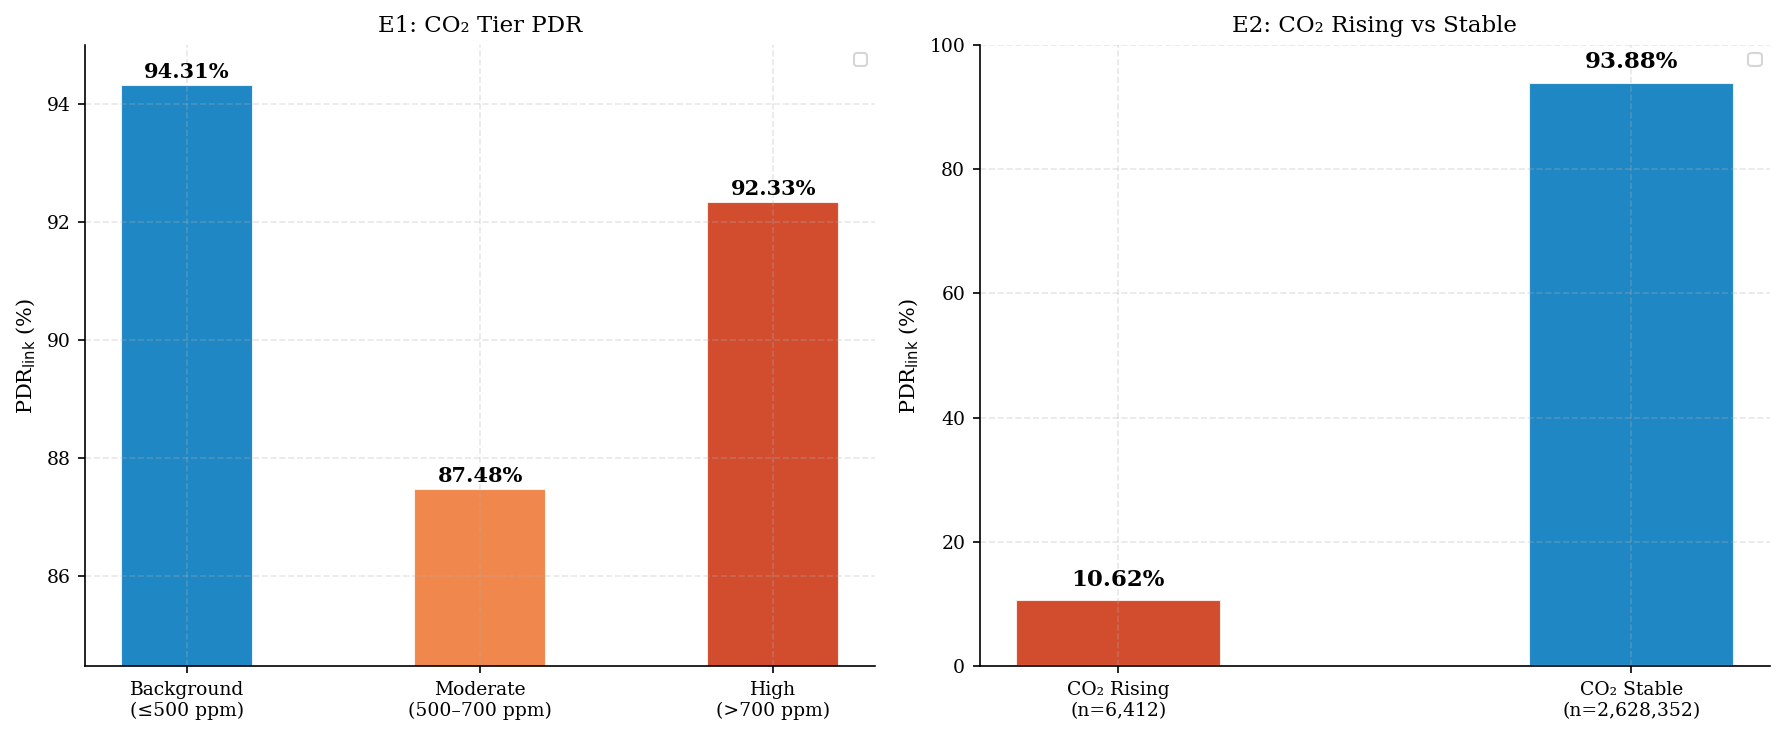

In [32]:
# --- Fig 03-A — Occupancy Events: CO2 Tier PDR + CO2 Rising PDR ---
tiers = ['background', 'moderate', 'high']
xlabs_e1 = ['Background\n(\u2264500 ppm)', 'Moderate\n(500\u2013700 ppm)', 'High\n(>700 ppm)']
pdrs_e1 = [pdr_grp(df_link[df_link['e1_co2_tier'] == t]) for t in tiers]

g1 = df_link[df_link['e2_co2_rising'] == 1]
g0 = df_link[df_link['e2_co2_rising'] == 0]
pdr_rising = pdr_grp(g1)
pdr_stable = pdr_grp(g0)
n_rising = len(g1)
n_stable = len(g0)

# campaign_mean = pdr_grp(df_link)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# =====================================================================
# E1: CO2 Tier — single-axis PDR bars (consistent with all other events)
# =====================================================================
colors_e1 = [C['blue'], C['orange'], C['red']]
bars_e1 = axes[0].bar(xlabs_e1, pdrs_e1,
                      color=colors_e1, width=0.45, alpha=0.88, edgecolor='white')

for bar, v in zip(bars_e1, pdrs_e1):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.05,
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# axes[0].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[0].set_ylabel('PDR$_{\\mathrm{link}}$ (%)')
axes[0].set_ylim(min(pdrs_e1) - 3, 95
                 )
axes[0].legend(fontsize=8)
axes[0].set_title('E1: CO\u2082 Tier PDR')

# =====================================================================
# E2: CO2 Rising vs Stable
# =====================================================================
xlabs_e2 = [f'CO\u2082 Rising\n(n={n_rising:,})', f'CO\u2082 Stable\n(n={n_stable:,})']
axes[1].bar(xlabs_e2, [pdr_rising, pdr_stable],
            color=[C['red'], C['blue']], width=0.4, alpha=0.88, edgecolor='white')

for i, v in enumerate([pdr_rising, pdr_stable]):
    axes[1].text(i, v + 1.5, f'{v:.2f}%',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# axes[1].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[1].set_ylabel('PDR$_{\\mathrm{link}}$ (%)')
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=8)
axes[1].set_title('E2: CO\u2082 Rising vs Stable')

# Global formatting
# fig.suptitle('Occupancy-Conditioned Reliability (E1, E2)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_a_occupancy_pdr')


## 3 · Temporal Event-Conditioned Reliability  *(§7.3 — RQ2)*

**Hypothesis:** Office hours show lower PDR due to higher human activity  
and increased RF interference from electronic devices. E4 (season) provides  
a complementary year-round view of seasonal variation.

Events: E3 (office hours), E4 (season)


In [6]:
print('=' * 60)
print('TEMPORAL EVENTS (E3–E4)')
print('=' * 60)

temporal_results = {}

# E3: office hours binary
print('\nE3: Office Hours vs Off-Peak')
r = pdr_compare(df_link, 'e3_office_hours', 1, 0)
print_comparison(r, 'Office hours (1) vs off-peak (0)')
temporal_results['E3_office'] = r

# E4: season
print('\nE4: Season PDR')
for season in ['autumn', 'winter', 'spring', 'summer']:
    g = df_link[df_link['e4_season'] == season]
    rx = len(g);
    lost = int(g['tx_loss'].sum())
    pdr = rx / (rx + lost) * 100
    print(f'    {season:<10}: {pdr:.2f}%  (n={rx:,})')

print('\nE4: Summer vs Winter (key comparison)')
r = pdr_compare(df_link, 'e4_season', 'summer', 'winter')
print_comparison(r, 'Summer vs Winter')
temporal_results['E4_summer_vs_winter'] = r


TEMPORAL EVENTS (E3–E4)

E3: Office Hours vs Off-Peak
  Office hours (1) vs off-peak (0)
                       1: 87.30%  (n=768,691)
                   not 1: 94.26%  (n=1,866,073)
    Difference        : -6.96 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0078


E4: Season PDR
    autumn    : 96.71%  (n=703,759)
    winter    : 86.56%  (n=593,575)
    spring    : 96.60%  (n=688,553)
    summer    : 88.40%  (n=648,877)

E4: Summer vs Winter (key comparison)
  Summer vs Winter
                  summer: 88.40%  (n=648,877)
                  winter: 86.56%  (n=593,575)
    Difference        : +1.85 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : 0.0137



  Saved: figures/03_b_temporal_pdr


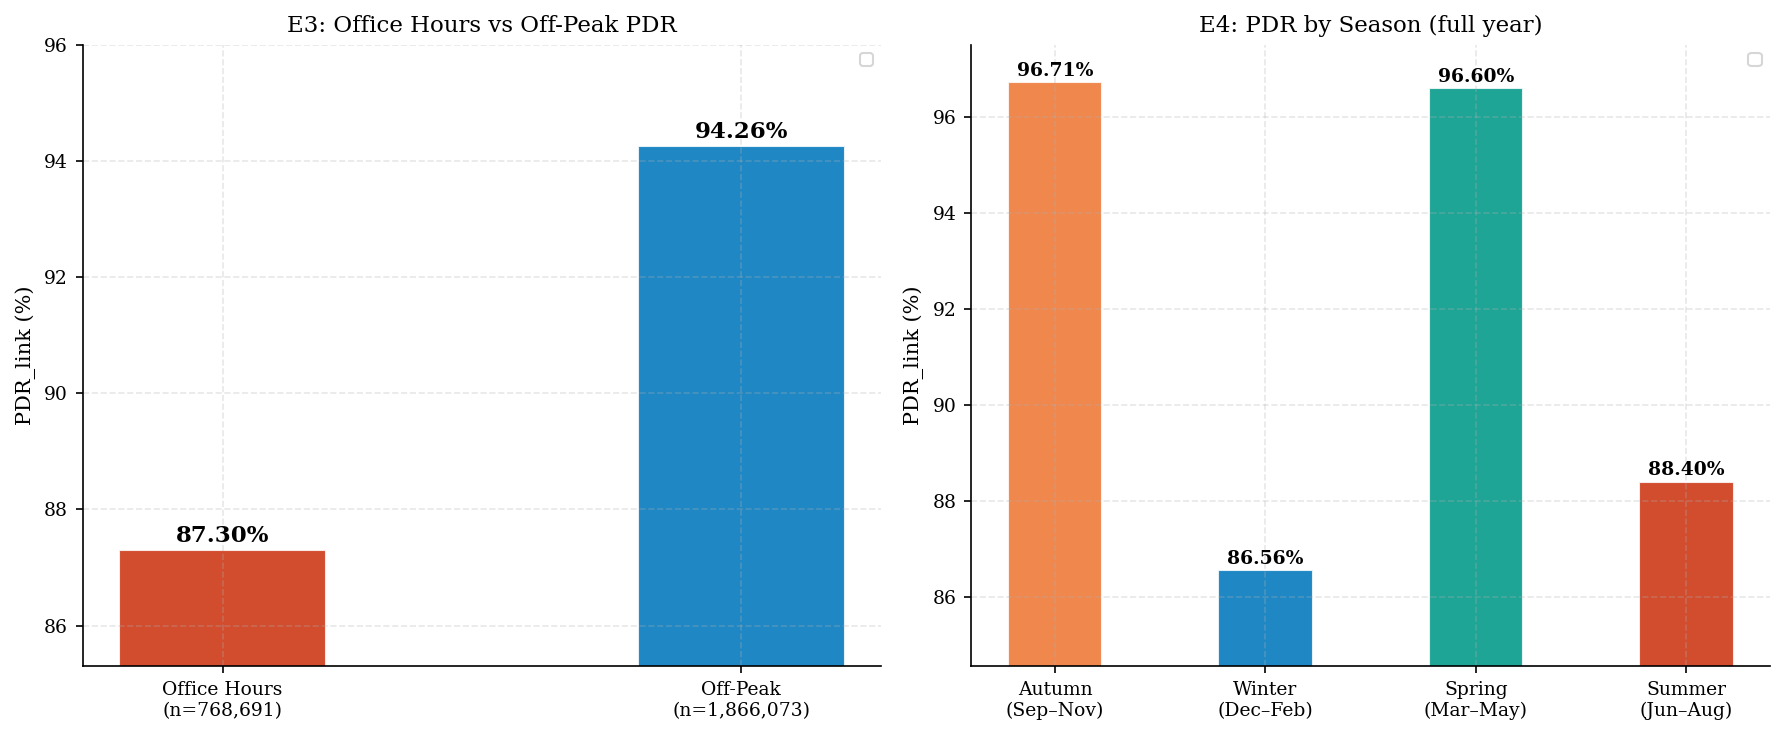

In [7]:
# Fig 03-B — Temporal Events PDR (E3–E4)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# campaign_mean = pdr_grp(df_link)

# =====================================================================
# E3: Office Hours vs Off-Peak PDR
# =====================================================================
oh_pdr = pdr_grp(df_link[df_link['e3_office_hours'] == 1])
op_pdr = pdr_grp(df_link[df_link['e3_office_hours'] == 0])
oh_n = (df_link['e3_office_hours'] == 1).sum()
op_n = (df_link['e3_office_hours'] == 0).sum()

axes[0].bar([f'Office Hours\n(n={oh_n:,})', f'Off-Peak\n(n={op_n:,})'],
            [oh_pdr, op_pdr],
            color=[C['red'], C['blue']], width=0.4, alpha=0.88, edgecolor='white')

# FIX: Changed axes[1] to axes[0] so the labels match the bars
for i2, v in enumerate([oh_pdr, op_pdr]):
    axes[0].text(i2, v + 0.05, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# axes[0].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[0].set_ylabel('PDR_link (%)')

# FIX: Dynamic Y-limit to prevent cutting off the text labels
axes[0].set_ylim(min(oh_pdr, op_pdr) - 2, 96)
axes[0].legend(fontsize=8)
axes[0].set_title('E3: Office Hours vs Off-Peak PDR')

# =====================================================================
# E4: PDR by Season (full year)
# =====================================================================
seasons = ['autumn', 'winter', 'spring', 'summer']
slabs = ['Autumn\n(Sep–Nov)', 'Winter\n(Dec–Feb)', 'Spring\n(Mar–May)', 'Summer\n(Jun–Aug)']
spdrs = [pdr_grp(df_link[df_link['e4_season'] == s]) for s in seasons]

bars = axes[1].bar(slabs, spdrs,
                   color=[C['orange'], C['blue'], C['green'], C['red']],
                   width=0.45, alpha=0.88, edgecolor='white')

for bar, v in zip(bars, spdrs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.05, f'{v:.2f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# axes[1].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[1].set_ylabel('PDR_link (%)')

# FIX: Changed axes[2] to axes[1] so the limits and title land on the correct plot
axes[1].set_ylim(min(spdrs) - 2, 97.5)
axes[1].legend(fontsize=8)
axes[1].set_title('E4: PDR by Season (full year)')

# Global formatting
# fig.suptitle('Temporal Events (E3–E4)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_b_temporal_pdr')

## 4 · Air Quality Events — PM2.5  *(§7.5.1 — RQ2)*

PM2.5 spikes mark activity bursts — cleaning, printing, cooking.  
Device-specific 90th percentile thresholds (E5) account for location differences.

Events: E5 (PM2.5 tier), E6 (PM2.5 spike)


In [8]:
print('=' * 60)
print('AIR QUALITY EVENTS — PM2.5 (§7.5.1)')
print('=' * 60)

air_quality_results = {}

# E5: PM2.5 tier
print('\nE5: PM2.5 Absolute Tier')
for tier in ['clean', 'moderate', 'elevated']:
    g = df_link[df_link['e5_pm25_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

# E6: PM2.5 spike
print('E6: PM2.5 Spike (device-specific 90th percentile)')
r = pdr_compare(df_link, 'e6_pm25_spike', 1, 0)
print_comparison(r, 'PM2.5 spike (1) vs normal (0)')
air_quality_results['E6_spike'] = r

AIR QUALITY EVENTS — PM2.5 (§7.5.1)

E5: PM2.5 Absolute Tier
    clean     : 92.20%  (n=2,599,834)
    moderate  : 86.48%  (n=34,498)
    elevated  : 75.00%  (n=432)
E6: PM2.5 Spike (device-specific 90th percentile)
  PM2.5 spike (1) vs normal (0)
                       1: 93.45%  (n=262,201)
                   not 1: 91.97%  (n=2,372,563)
    Difference        : +1.47 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0227



  Saved: figures/03_c_air_quality_pdr


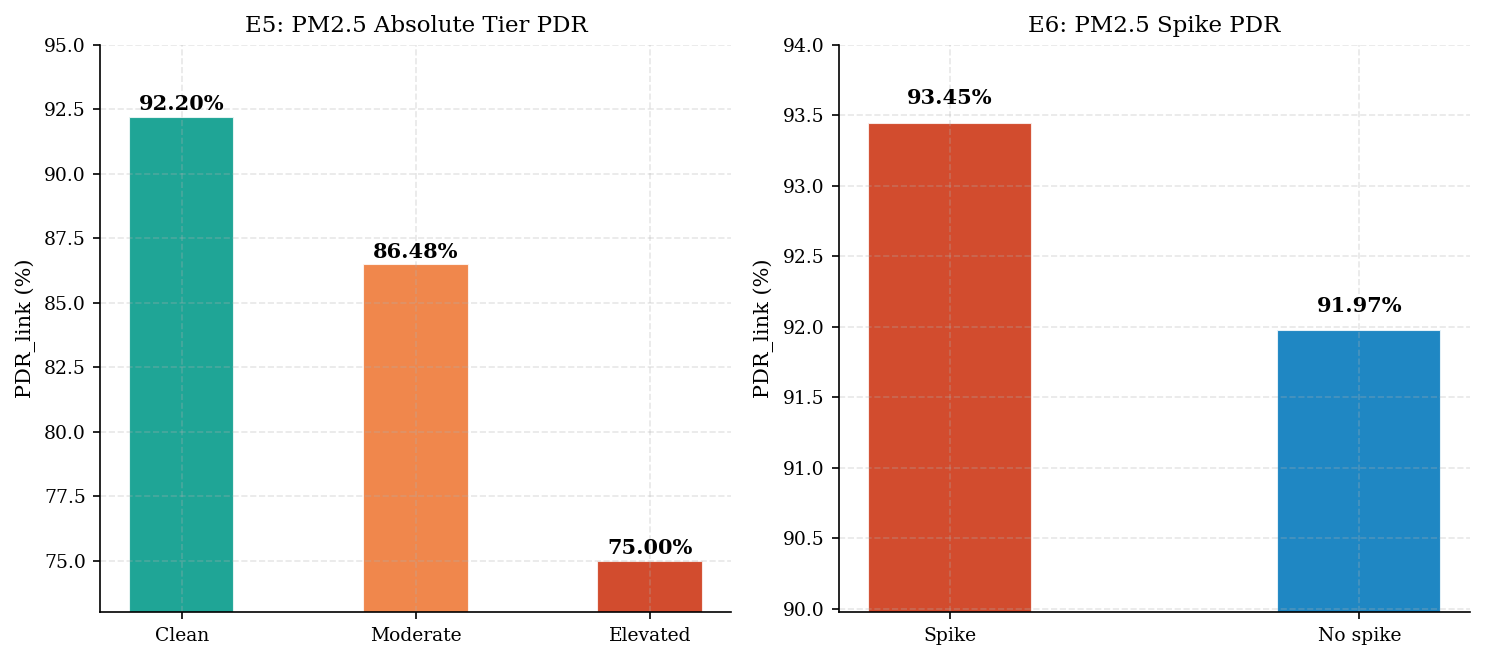

In [9]:
# Fig 03-C — Air Quality Events (E5, E6)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# axes[0] = E5: PM2.5 absolute tier
pm_tiers = ['clean', 'moderate', 'elevated']
pm_labs = ['Clean', 'Moderate', 'Elevated']
pm_pdrs = [pdr_grp(df_link[df_link['e5_pm25_tier'] == t])
           if len(df_link[df_link['e5_pm25_tier'] == t]) > 0 else 0 for t in pm_tiers]

axes[0].bar(pm_labs, pm_pdrs,
            color=[C['green'], C['orange'], C['red']], width=0.45, alpha=0.88, edgecolor='white')
for i2, v in enumerate(pm_pdrs):
    if v > 0:
        axes[0].text(i2, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylabel('PDR_link (%)')
valid_pdrs = [v for v in pm_pdrs if v > 0]
axes[0].set_ylim(min(valid_pdrs) - 2 if valid_pdrs else 0, 95)
axes[0].set_title('E5: PM2.5 Absolute Tier PDR')

# axes[1] = E6: PM2.5 spike
g_spike = df_link[df_link['e6_pm25_spike'] == 1]
g_norm  = df_link[df_link['e6_pm25_spike'] == 0]
vals_e6 = [pdr_grp(g_spike), pdr_grp(g_norm)]

axes[1].bar(['Spike', 'No spike'], vals_e6,
            color=[C['red'], C['blue']], width=0.4, alpha=0.88, edgecolor='white')
for i2, v in enumerate(vals_e6):
    axes[1].text(i2, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylabel('PDR_link (%)')
axes[1].set_ylim(min(vals_e6) - 2, 94)
axes[1].set_title('E6: PM2.5 Spike PDR')

# fig.suptitle('Air Quality Events (E5, E6)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_c_air_quality_pdr')

## 5 · Atmospheric Events  *(§7.5.2 — RQ2)*

Events: E7 (temperature tier), E8 (humidity tier)


In [10]:
print('=' * 60)
print('ATMOSPHERIC EVENTS (E7–E8)')
print('=' * 60)

atm_results = {}

# E7: temperature tier
print('\nE7: Temperature Tier PDR')
for tier in ['cool', 'moderate', 'warm']:
    g = df_link[df_link['e7_temp_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

print('\nE7: Warm vs Cool (key comparison)')
r = pdr_compare(df_link, 'e7_temp_tier', 'warm', 'cool')
print_comparison(r, 'Warm vs Cool')
atm_results['E7_warm_vs_cool'] = r

# E8: humidity tier
print('\nE8: Humidity Tier PDR')
for tier in ['dry', 'normal', 'humid']:
    g = df_link[df_link['e8_humidity_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

print('\nE8: Humid vs Dry (key comparison)')
r = pdr_compare(df_link, 'e8_humidity_tier', 'humid', 'dry')
print_comparison(r, 'Humid vs Dry')
atm_results['E8_humid_vs_dry'] = r


ATMOSPHERIC EVENTS (E7–E8)

E7: Temperature Tier PDR
    cool      : 91.26%  (n=876,914)
    moderate  : 94.13%  (n=886,614)
    warm      : 91.00%  (n=871,236)

E7: Warm vs Cool (key comparison)
  Warm vs Cool
                    warm: 91.00%  (n=871,236)
                    cool: 91.26%  (n=876,914)
    Difference        : -0.26 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : 0.0074


E8: Humidity Tier PDR
    dry       : 95.78%  (n=387,659)
    normal    : 91.51%  (n=2,246,372)
    humid     : 94.70%  (n=733)

E8: Humid vs Dry (key comparison)
  Humid vs Dry
                   humid: 94.70%  (n=733)
                     dry: 95.78%  (n=387,659)
    Difference        : -1.07 pp
    p-value           : 0.0178  ✓ SIGNIFICANT
    Effect size (r)   : -0.0133



  Saved: figures/03_d_atmospheric_pdr


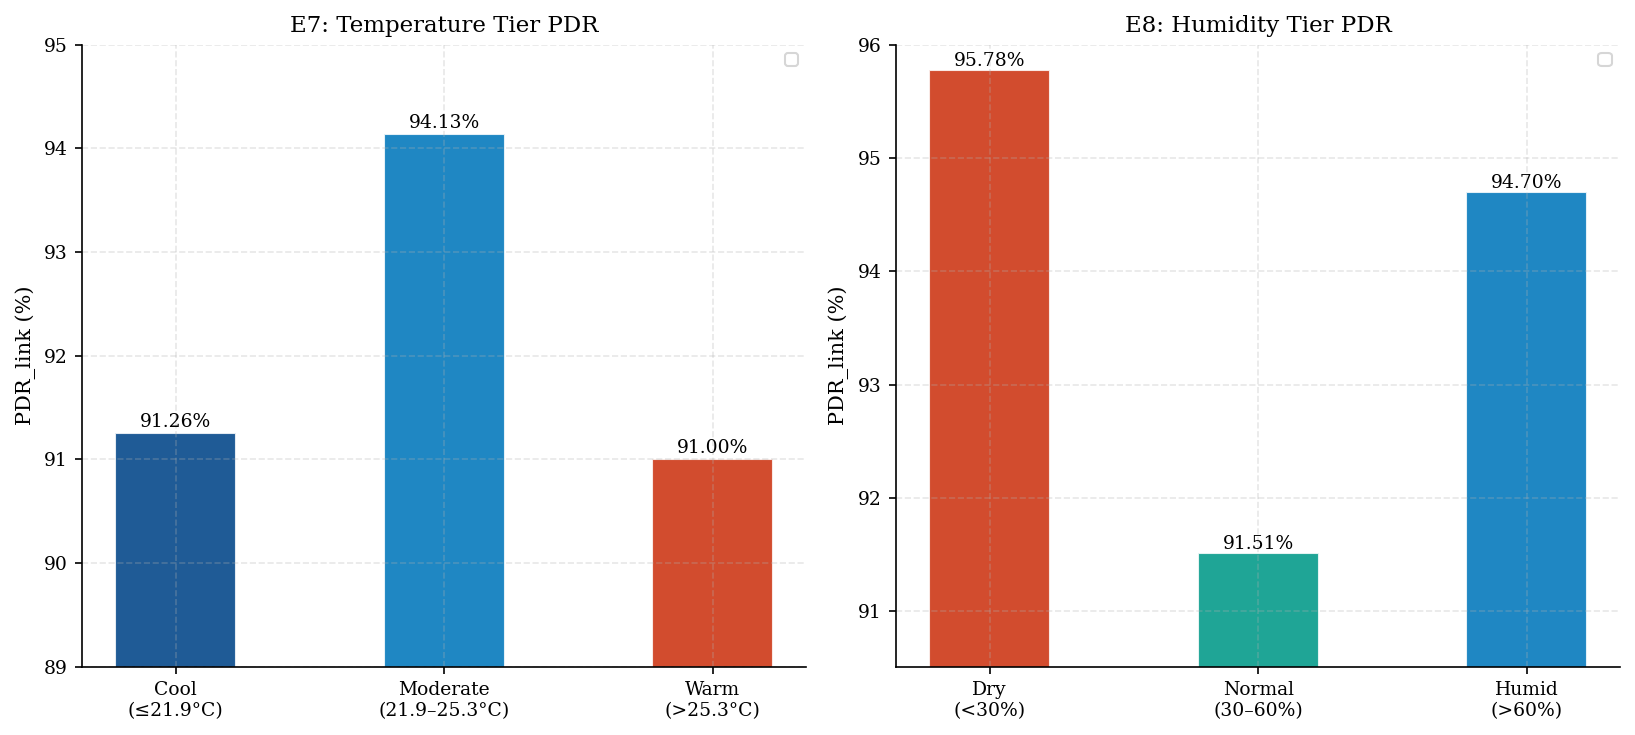

In [33]:
# Fig 03-D — Atmospheric Events PDR (E7–E8)
fig, axes = plt.subplots(1, 2, figsize=(11, 5), squeeze=False)
# campaign_mean = pdr_grp(df_link)

# E7: temperature — 3 absolute tiers (cool ≤ 21.9°C, moderate 21.9–25.3°C, warm > 25.3°C)
tt = ['cool', 'moderate', 'warm']
tt_labs = ['Cool\n(≤21.9°C)', 'Moderate\n(21.9–25.3°C)', 'Warm\n(>25.3°C)']
tt_pdrs = [pdr_grp(df_link[df_link['e7_temp_tier'] == t]) for t in tt]
bars = axes[0, 0].bar(tt_labs, tt_pdrs,
                       color=[C['navy'], C['blue'], C['red']],
                       width=0.45, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, tt_pdrs):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.2f}%',
                    ha='center', va='bottom', fontsize=9)
# axes[0, 0].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[0, 0].set_ylabel('PDR_link (%)')
axes[0, 0].set_ylim(min(tt_pdrs) - 2, 95)
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_title('E7: Temperature Tier PDR')

# E8: humidity — ASHRAE 55 comfort bands (dry < 30%, normal 30–60%, humid > 60%)
ht = ['dry', 'normal', 'humid']
ht_labs = ['Dry\n(<30%)', 'Normal\n(30–60%)', 'Humid\n(>60%)']
ht_pdrs = [pdr_grp(df_link[df_link['e8_humidity_tier'] == t])
           if len(df_link[df_link['e8_humidity_tier'] == t]) > 0 else 0 for t in ht]
bars = axes[0, 1].bar(ht_labs, ht_pdrs,
                       color=[C['red'], C['green'], C['blue']],
                       width=0.45, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, ht_pdrs):
    if v > 0:
        axes[0, 1].text(bar.get_x() + bar.get_width() / 2, v , f'{v:.2f}%',
                        ha='center', va='bottom', fontsize=9)
# axes[0, 1].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[0, 1].set_ylabel('PDR_link (%)')
valid_pdrs = [v for v in ht_pdrs if v > 0]
axes[0, 1].set_ylim((min(valid_pdrs) - 1 if valid_pdrs else 0), 96)
axes[0, 1].legend(fontsize=8)
axes[0, 1].set_title('E8: Humidity Tier PDR')

# fig.suptitle('Atmospheric Events (E7–E8)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_d_atmospheric_pdr')


## 6 · Spreading Factor and SF×Occupancy Interaction  *(§7.6 — RQ2)*

**Hypothesis:** Higher SF → longer ToA → wider collision window → lower PDR.

**Novel joint analysis:** SF × CO₂ interaction — during high-occupancy periods
the PDR gap between low-SF and high-SF transmissions should widen, since longer
airtime at high SF increases the probability of overlapping with concurrent
transmissions from other devices and networks.

Event: E9 (spreading factor), combined with E1 (CO₂ tier)


In [12]:
print('=' * 60)
print('SPREADING FACTOR EVENT (E9)')
print('=' * 60)

TOA_MS = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6, 11: 987.1, 12: 1810.4}
sf_pdrs = {}
sf_results = {}

print('\nE9: PDR by Spreading Factor')
for sf in [7, 8, 9, 10, 11, 12]:
    g = df_link[df_link['e9_sf'] == sf]
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    pdr = rx / (rx + lost) * 100
    sf_pdrs[sf] = pdr
    print(f'    SF{sf:2d} (ToA={TOA_MS[sf]:7.1f}ms): {pdr:.2f}%  (n={rx:,})')

print(f'\n    PDR drop SF7→SF12: {sf_pdrs[7] - sf_pdrs[12]:.2f} pp')

print('\nE9: SF12 vs SF7 (key comparison)')
r = pdr_compare(df_link, 'e9_sf', 12, 7)
print_comparison(r, 'SF12 vs SF7')
sf_results['E9_sf12_vs_sf7'] = r


SPREADING FACTOR EVENT (E9)

E9: PDR by Spreading Factor
    SF 7 (ToA=   71.9ms): 93.28%  (n=536,991)
    SF 8 (ToA=  133.6ms): 93.19%  (n=534,512)
    SF 9 (ToA=  246.8ms): 91.77%  (n=518,710)
    SF10 (ToA=  452.6ms): 93.65%  (n=500,805)
    SF11 (ToA=  987.1ms): 90.45%  (n=269,199)
    SF12 (ToA= 1810.4ms): 87.59%  (n=274,547)

    PDR drop SF7→SF12: 5.69 pp

E9: SF12 vs SF7 (key comparison)
  SF12 vs SF7
                      12: 87.59%  (n=274,547)
                       7: 93.28%  (n=536,991)
    Difference        : -5.69 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0187



  Saved: figures/03_e_sf_pdr


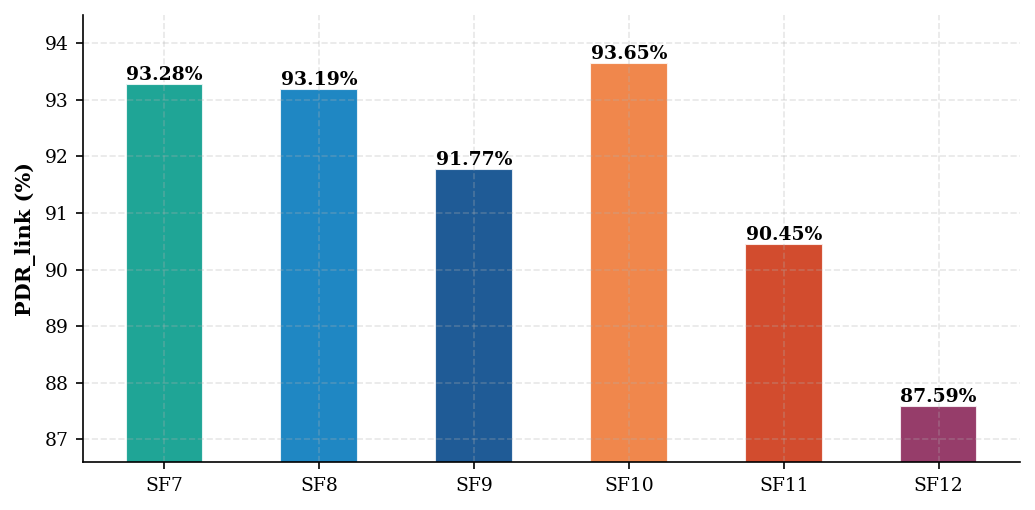

In [30]:
# Fig 03-E — PDR by Spreading Factor (E9)
fig, ax = plt.subplots(figsize=(7, 3.5))

sfs = [7, 8, 9, 10, 11, 12]
sf_pdr_vals = []
sf_labs = []

for sf in sfs:
    g = df_link[df_link['e9_sf'] == sf]
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    pdr = (rx / (rx + lost) * 100) if (rx + lost) > 0 else 0
    sf_pdr_vals.append(pdr)
    sf_labs.append(f'SF{sf}')

bar_colors = [C['green'], C['blue'], C['navy'], C['orange'], C['red'], C['brown']]

ax.bar(sf_labs, sf_pdr_vals, color=bar_colors, width=0.5, alpha=0.88, edgecolor='white')

for i2, v in enumerate(sf_pdr_vals):
    if v > 0:
        ax.text(i2, v , f'{v:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('PDR_link (%)', fontweight='bold')
ax.set_ylim(min(sf_pdr_vals) - 1 if sf_pdr_vals else 0, 94.5)
# ax.set_title(f'E9: PDR by Spreading Factor\n(PDR drop SF7→SF12: {sf_pdr_vals[0] - sf_pdr_vals[-1]:.2f} pp)',
#               fontsize=11, fontweight='bold')

fig.tight_layout()
save_fig(fig, '03_e_sf_pdr')


### SF × CO₂ Interaction  *(§7.6 — novel finding)*

The PDR gap between SF7 and SF12 is computed separately within the
background and high CO₂ tiers (E1). A widening gap under high occupancy
indicates that the airtime penalty of high SF compounds with collision
probability, since longer transmissions overlap with more concurrent
activity in busier periods.


SF × CO2 INTERACTION (E9 × E1)

  CO2 tier: background
    PDR SF7  : 94.67%  (n=348,323)
    PDR SF12 : 95.46%  (n=155,707)
    Gap      : -0.79 pp

  CO2 tier: high
    PDR SF7  : 96.63%  (n=43,146)
    PDR SF12 : 90.47%  (n=27,444)
    Gap      : 6.15 pp

Gap widening (high CO2 vs background): +6.94 pp
  Saved: figures/03_f_sf_co2_interaction


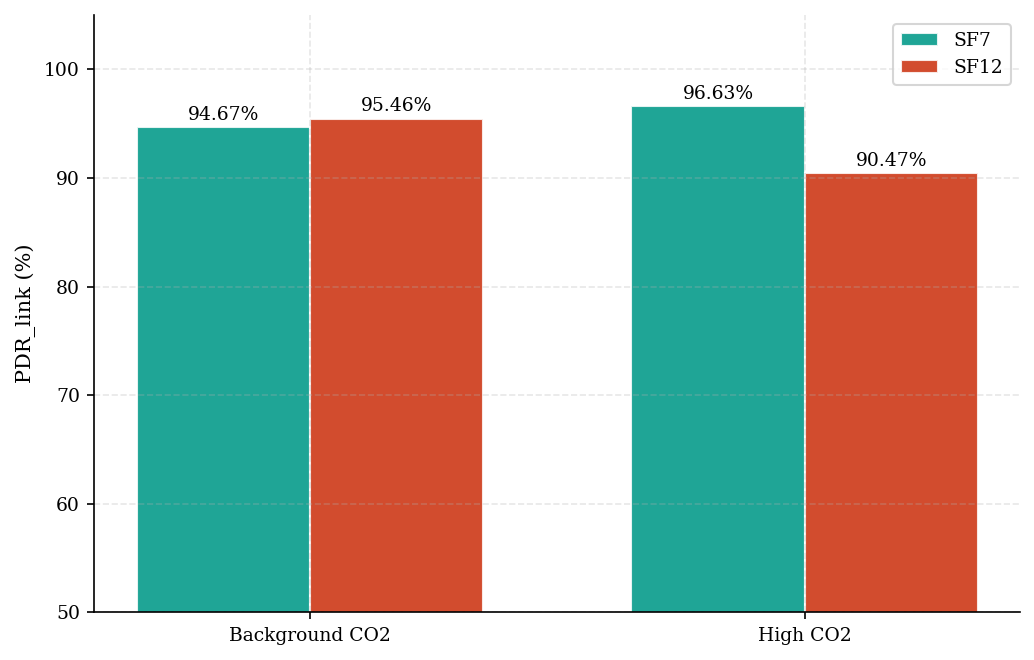

In [14]:
print('=' * 60)
print('SF × CO2 INTERACTION (E9 × E1)')
print('=' * 60)

joint_results = {}

for co2_tier in ['background', 'high']:
    sub = df_link[df_link['e1_co2_tier'] == co2_tier]
    pdr_sf7 = pdr_grp(sub[sub['e9_sf'] == 7])
    pdr_sf12 = pdr_grp(sub[sub['e9_sf'] == 12])
    gap = pdr_sf7 - pdr_sf12
    joint_results[co2_tier] = {
        'pdr_sf7': pdr_sf7, 'pdr_sf12': pdr_sf12, 'gap': gap,
        'n_sf7': int((sub['e9_sf'] == 7).sum()),
        'n_sf12': int((sub['e9_sf'] == 12).sum()),
    }
    print(f'\n  CO2 tier: {co2_tier}')
    print(f'    PDR SF7  : {pdr_sf7:.2f}%  (n={joint_results[co2_tier]["n_sf7"]:,})')
    print(f'    PDR SF12 : {pdr_sf12:.2f}%  (n={joint_results[co2_tier]["n_sf12"]:,})')
    print(f'    Gap      : {gap:.2f} pp')

widening = joint_results['high']['gap'] - joint_results['background']['gap']
print(f'\nGap widening (high CO2 vs background): {widening:+.2f} pp')


# Fig 03-F — SF x CO2 interaction
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(2)
w = 0.35

sf7_vals = [joint_results['background']['pdr_sf7'], joint_results['high']['pdr_sf7']]
sf12_vals = [joint_results['background']['pdr_sf12'], joint_results['high']['pdr_sf12']]

b1 = ax.bar(x - w / 2, sf7_vals, w, color=C['green'], alpha=0.88, label='SF7', edgecolor='white')
b2 = ax.bar(x + w / 2, sf12_vals, w, color=C['red'], alpha=0.88, label='SF12', edgecolor='white')

for bar, v in zip(b1, sf7_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
for bar, v in zip(b2, sf12_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(['Background CO2', 'High CO2'])
ax.set_ylabel('PDR_link (%)')
ax.set_ylim(50, 105)
ax.legend(fontsize=9)
# ax.set_title(f'SF7 vs SF12 PDR Gap by CO2 Tier\n'
#              f'Gap widens by {widening:+.2f} pp under high occupancy', fontsize=11, fontweight='bold')

fig.tight_layout()
save_fig(fig, '03_f_sf_co2_interaction')


## 7 · Signal Context Event  *(§7.5 — RQ2)*

**Hypothesis:** Weaker signal → higher loss rate.

E10 (ESP, effective signal power) uses the ThingPark six-tier classification
of the last received packet as a proxy for channel state. A flat PDR across
ESP tiers would indicate that signal quality is not the dominant loss driver,
supporting the collision-dominated hypothesis.

Event: E10 (ESP tier)


In [15]:
print('=' * 60)
print('SIGNAL CONTEXT EVENT (E10)')
print('=' * 60)

signal_results = {}

# E10: ESP tier — 3 analytical tiers
print('E10: PDR by ESP Tier (poor / moderate / strong)')
for tier in ['poor', 'moderate', 'strong']:
    g = df_link[df_link['e10_esp_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

r = pdr_compare(df_link, 'e10_esp_tier', 'poor', 'strong')
print()
print_comparison(r, 'Poor ESP vs Strong ESP')
signal_results['E10_poor_vs_strong'] = r

SIGNAL CONTEXT EVENT (E10)
E10: PDR by ESP Tier (poor / moderate / strong)
    poor        : 89.04%  (n=230,108)
    moderate    : 95.78%  (n=116,196)
    strong      : 92.26%  (n=2,288,460)

  Poor ESP vs Strong ESP
                    poor: 89.04%  (n=230,108)
                  strong: 92.26%  (n=2,288,460)
    Difference        : -3.21 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0142



  Saved: figures/03_g_signal_context_pdr


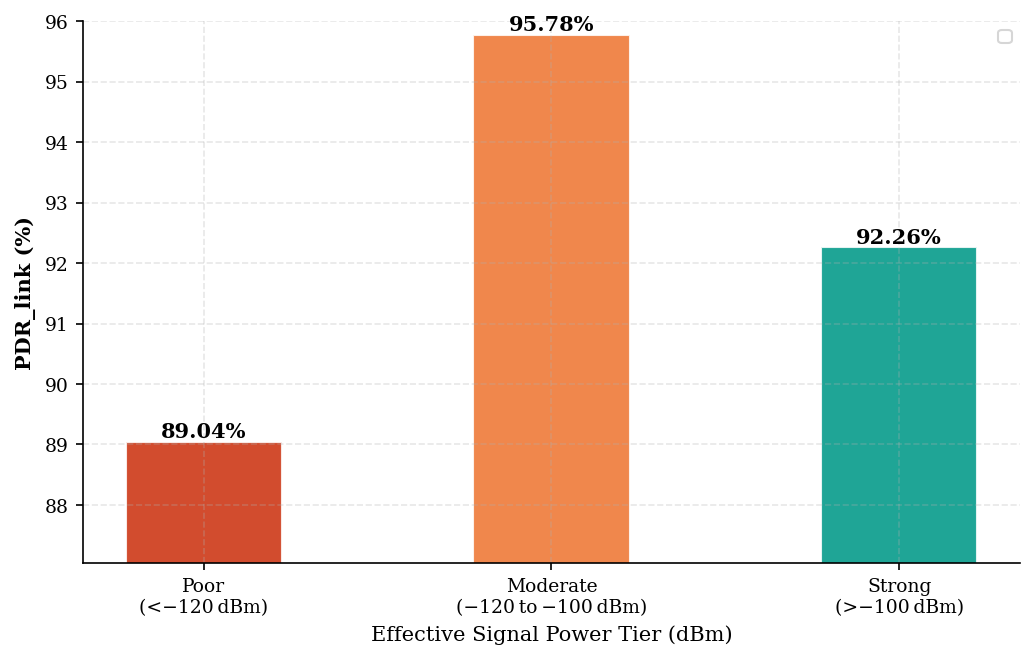

In [27]:
# Fig 03-G — Signal Context PDR (E10) — 3 analytical tiers
fig, ax = plt.subplots(figsize=(7, 4.5))

et = ['poor', 'moderate', 'strong']
et_labs = ['Poor\n(<−120\u202fdBm)', 'Moderate\n(−120\u202fto\u202f−100\u202fdBm)', 'Strong\n(>−100\u202fdBm)']
et_pdrs = [pdr_grp(df_link[df_link['e10_esp_tier'] == t])
           if len(df_link[df_link['e10_esp_tier'] == t]) > 0 else 0
           for t in et]
et_colors = [C['red'], C['orange'], C['green']]

bars = ax.bar(et_labs, et_pdrs, color=et_colors, width=0.45, alpha=0.88, edgecolor='white')

for bar, v in zip(bars, et_pdrs):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, v,
                f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('PDR_link (%)', fontweight='bold')
ax.set_xlabel('Effective Signal Power Tier (dBm)')
valid_pdrs = [v for v in et_pdrs if v > 0]
ax.set_ylim((min(valid_pdrs) - 2 if valid_pdrs else 0), 96)
# ax.axhline(y=pdr_grp(df_link), color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
ax.legend(fontsize=8)
# ax.set_title('E10: ESP Tier PDR (poor / moderate / strong)', fontsize=11, fontweight='bold')

fig.tight_layout()
save_fig(fig, '03_g_signal_context_pdr')

## 8 · Complete Event Summary Table  *(Tables 7.x)*

All 10 events ranked by effect size r — maps directly to thesis Chapter 7 tables.


In [17]:
print('=' * 60)
print('ALL EVENTS — PDR SUMMARY (E1–E10, ranked by effect size r)')
print('=' * 60)

all_results = []

binary_events = [
    ('E2', 'e2_co2_rising', 1, 0, 'CO2 rising vs stable'),
    ('E3', 'e3_office_hours', 1, 0, 'Office hours vs off-peak'),
    ('E6', 'e6_pm25_spike', 1, 0, 'PM2.5 spike vs normal'),
]
cat_events = [
    ('E1', 'e1_co2_tier', 'high', 'background', 'High CO2 vs Background'),
    ('E4', 'e4_season', 'summer', 'winter', 'Summer vs Winter'),
    ('E5', 'e5_pm25_tier', 'elevated', 'clean', 'Elevated vs Clean PM2.5'),
    ('E7', 'e7_temp_tier', 'warm', 'cool', 'Warm vs Cool'),
    ('E8', 'e8_humidity_tier', 'humid', 'dry', 'Humid vs Dry'),
    ('E9', 'e9_sf', 12, 7, 'SF12 vs SF7'),
    ('E10', 'e10_esp_tier', 'poor', 'strong', 'Poor vs Strong ESP'),
]

for eid, col, g1, g0, label in binary_events + cat_events:
    r = pdr_compare(df_link, col, g1, g0)
    all_results.append({
        'Event': eid, 'Comparison': label,
        'PDR_active': r['pdr1'], 'PDR_inactive': r['pdr0'],
        'Diff_pp': r['diff_pp'], 'p_value': r['p_value'],
        'Effect_r': r['effect_r'], 'Significant': r['significant']
    })

results_df = pd.DataFrame(all_results).sort_values('Effect_r')
plot_df = results_df.copy()

print(f"{'Event':<6} {'Comparison':<35} {'PDR_active':>11} {'PDR_inactive':>13} "
      f"{'Diff(pp)':>10} {'p-value':>9} {'r':>7} {'Sig':>5}")
print('-' * 100)
for _, row in results_df.iterrows():
    sig = '✓' if row['Significant'] else '✗'
    print(f"{row['Event']:<6} {row['Comparison']:<35} {row['PDR_active']:>10.2f}% "
          f"{row['PDR_inactive']:>12.2f}% {row['Diff_pp']:>+9.2f} "
          f"{row['p_value']:>9.4f} {row['Effect_r']:>7.4f} {sig:>5}")


ALL EVENTS — PDR SUMMARY (E1–E10, ranked by effect size r)
Event  Comparison                           PDR_active  PDR_inactive   Diff(pp)   p-value       r   Sig
----------------------------------------------------------------------------------------------------
E2     CO2 rising vs stable                     10.62%        93.88%    -83.26    0.0000 -0.2527     ✓
E5     Elevated vs Clean PM2.5                  75.00%        92.20%    -17.20    0.0000 -0.1190     ✓
E1     High CO2 vs Background                   92.33%        94.31%     -1.98    0.0000 -0.0241     ✓
E6     PM2.5 spike vs normal                    93.45%        91.97%     +1.47    0.0000 -0.0227     ✓
E9     SF12 vs SF7                              87.59%        93.28%     -5.69    0.0000 -0.0187     ✓
E10    Poor vs Strong ESP                       89.04%        92.26%     -3.21    0.0000 -0.0142     ✓
E8     Humid vs Dry                             94.70%        95.78%     -1.07    0.0178 -0.0133     ✓
E3     Office h

  Saved: figures/03_h_event_summary_forest


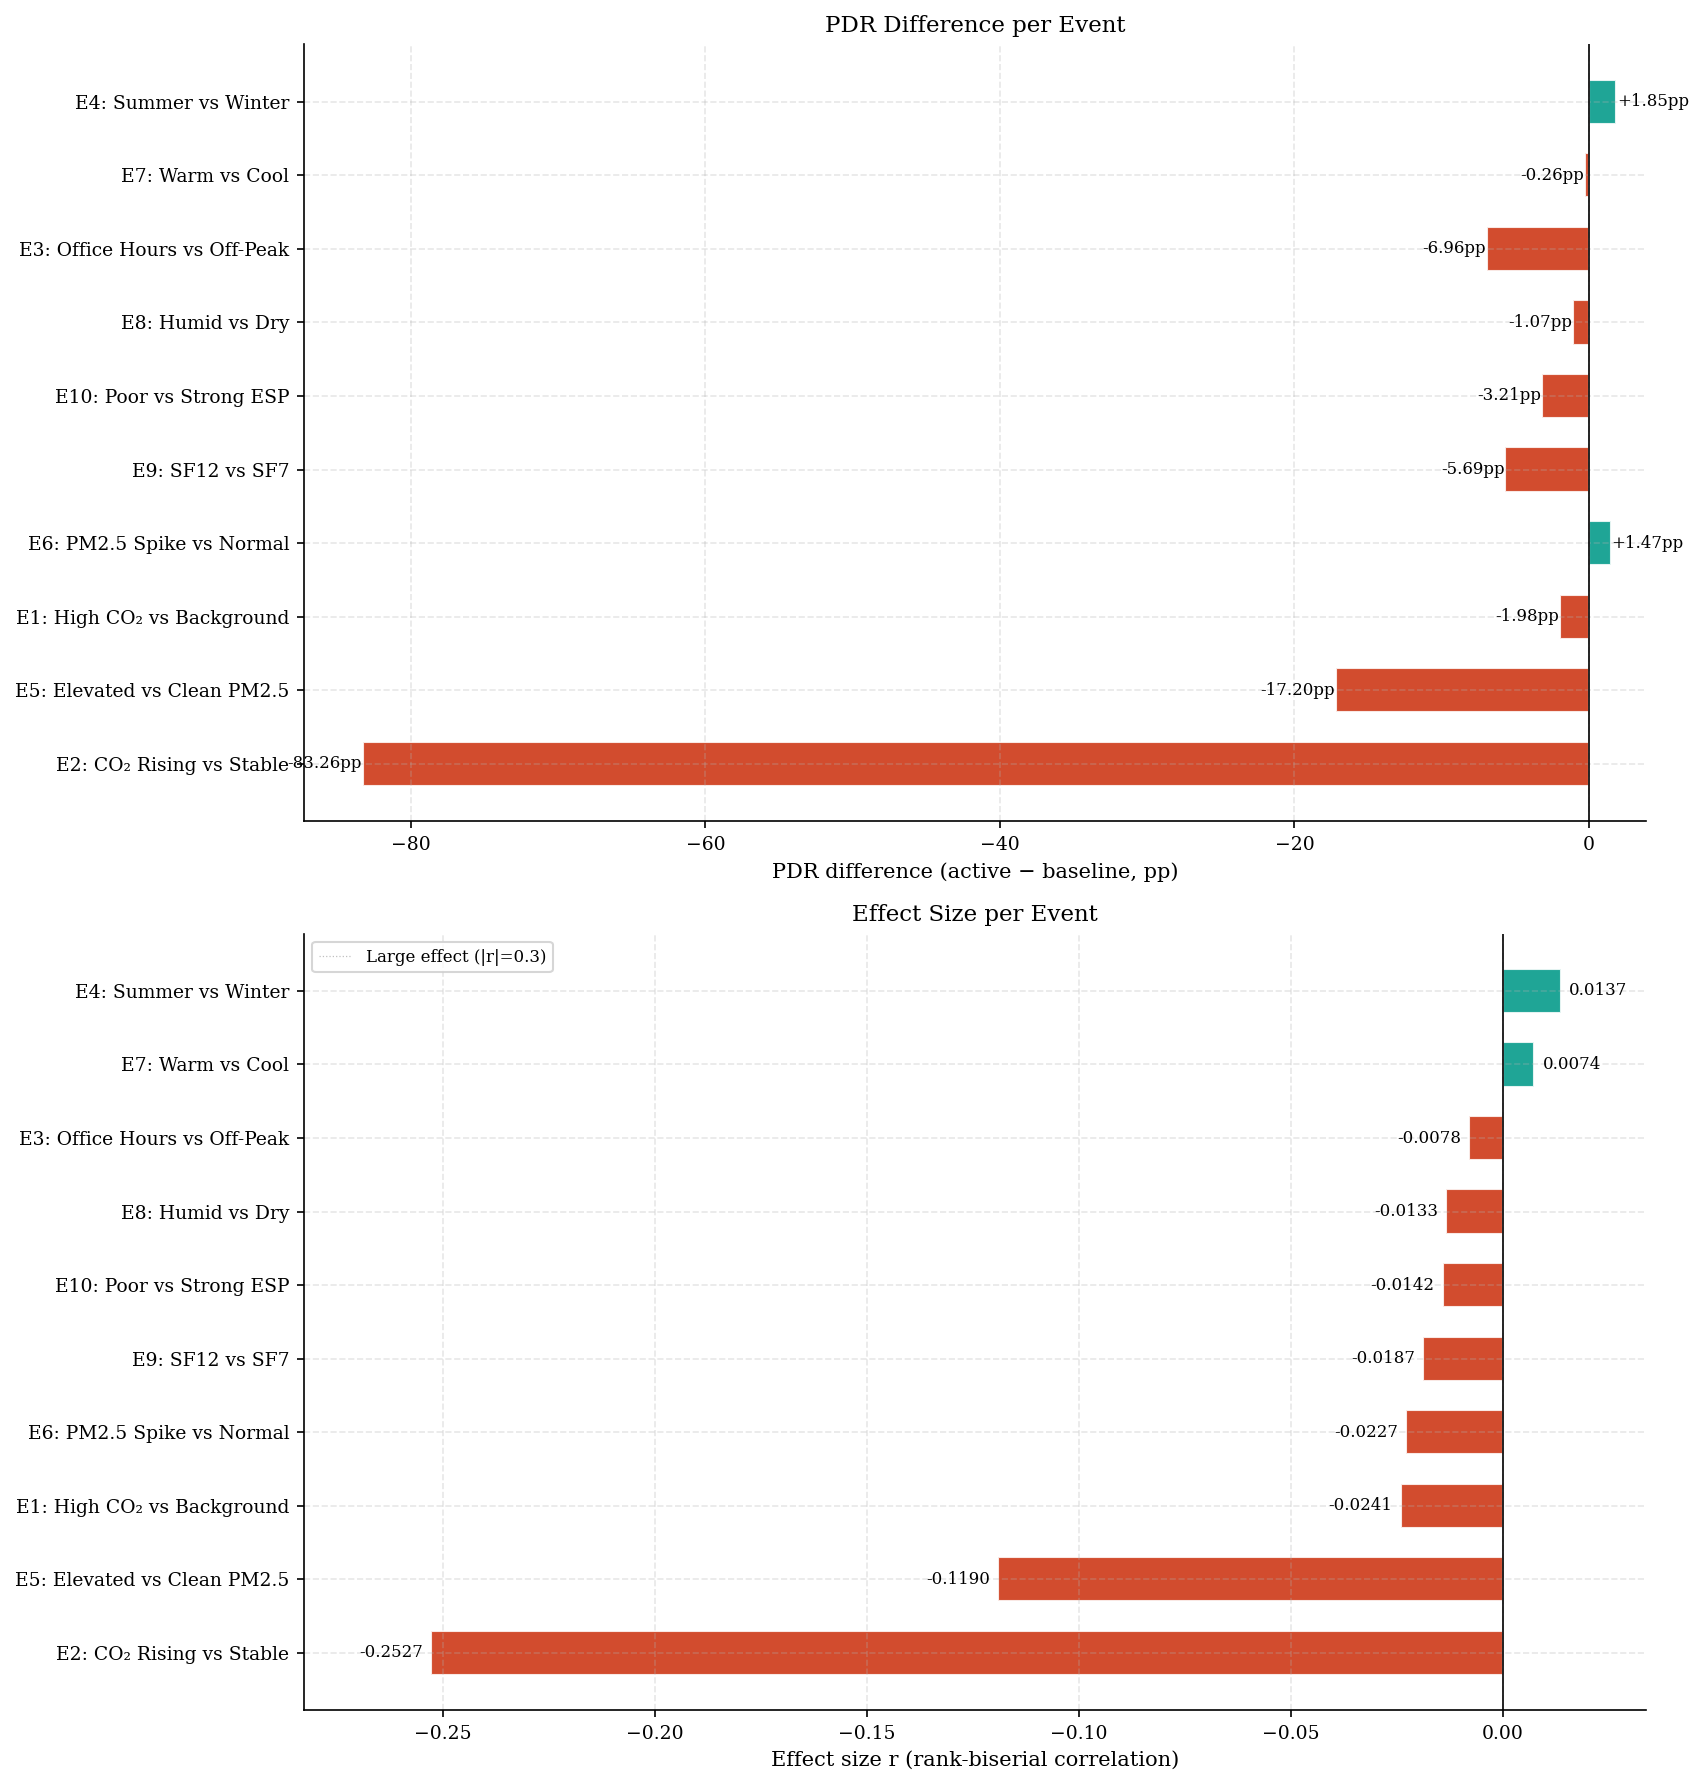

In [18]:
# Fig 03-H — Event Summary Forest Plot
plot_df = plot_df.sort_values('Effect_r')
event_labels = {
    'E1': 'E1: High CO₂ vs Background',
    'E2': 'E2: CO₂ Rising vs Stable',

    'E3': 'E3: Office Hours vs Off-Peak',
    'E4': 'E4: Summer vs Winter',
    'E5': 'E5: Elevated vs Clean PM2.5',
    'E6': 'E6: PM2.5 Spike vs Normal',
    'E7': 'E7: Warm vs Cool',
    'E8': 'E8: Humid vs Dry',
    'E9': 'E9: SF12 vs SF7',
    'E10': 'E10: Poor vs Strong ESP',
}
plot_df['label'] = plot_df['Event'].map(event_labels)

fig, axes = plt.subplots(2, 1, figsize=(13, 12))

# top: PDR difference in pp
colors = [C['red'] if v < 0 else C['green'] for v in plot_df['Diff_pp']]
bars = axes[0].barh(plot_df['label'], plot_df['Diff_pp'],
                    color=colors, alpha=0.88, edgecolor='white', height=0.6)
axes[0].axvline(x=0, color='black', lw=0.8, ls='-')
for bar, v in zip(bars, plot_df['Diff_pp']):
    axes[0].text(v + (0.05 if v >= 0 else -0.05),
                 bar.get_y() + bar.get_height() / 2,
                 f'{v:+.2f}pp', ha='left' if v >= 0 else 'right',
                 va='center', fontsize=8)
axes[0].set_xlim(min(plot_df['Diff_pp']) - 4, max(plot_df['Diff_pp']) + 2)
axes[0].set_xlabel('PDR difference (active − baseline, pp)')
axes[0].set_title('PDR Difference per Event')

# bottom: effect size r
colors2 = [C['red'] if v < 0 else C['green'] for v in plot_df['Effect_r']]
bars2 = axes[1].barh(plot_df['label'], plot_df['Effect_r'],
                     color=colors2, alpha=0.88, edgecolor='white', height=0.6)
axes[1].axvline(x=0, color='black', lw=0.8, ls='-')
axes[1].axvline(x=-0.3, color='grey', lw=0.6, ls=':', alpha=0.5, label='Large effect (|r|=0.3)')
axes[1].axvline(x=0.3, color='grey', lw=0.6, ls=':', alpha=0.5)
for bar, v in zip(bars2, plot_df['Effect_r']):
    axes[1].text(v + (0.002 if v >= 0 else -0.002),
                 bar.get_y() + bar.get_height() / 2,
                 f'{v:.4f}', ha='left' if v >= 0 else 'right',
                 va='center', fontsize=8)
axes[1].set_xlim(min(plot_df['Effect_r']) - 0.03, max(plot_df['Effect_r']) + 0.02)
axes[1].set_xlabel('Effect size r (rank-biserial correlation)')
axes[1].set_title('Effect Size per Event')
axes[1].legend(fontsize=8)

# fig.suptitle('All Events — Effect Size and PDR Impact Summary\n'
#              'Sorted by effect size r (E1–E10)',  # 10 events
#              fontsize=11, fontweight='bold')
fig.tight_layout()
fig.subplots_adjust(left=0.28)
save_fig(fig, '03_h_event_summary_forest')

## 10 · Logistic Regression — Loss Risk Model  *(§7.7 — RQ3)*

**RQ3:** Which conditions are most strongly associated with loss risk?

Binary outcome: `y = 1[tx_loss > 0]`
Predictors: all 10 events + device-ID fixed effects (ED0 as reference).
**OR > 1** → increased loss probability. 95% CI from bootstrap.

Change `N_BOOT = 10` for testing, `N_BOOT = 100` for final thesis run.


In [19]:
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample

df_link['loss_occurred'] = (df_link['tx_loss'] > 0).astype(int)

feature_df = pd.get_dummies(df_link[[
    'e1_co2_tier', 'e2_co2_rising',
    'e3_office_hours', 'e4_season',
    'e6_pm25_spike', 'e5_pm25_tier',
    'e7_temp_tier', 'e8_humidity_tier',
    'e9_sf', 'e10_esp_tier',
    'device_id'
]], drop_first=True).astype(float)

X = feature_df.values
feat_names = feature_df.columns.tolist()
y = df_link['loss_occurred'].values

# ── change this one value only ──────────────────────────
N_BOOT = 10  # 10 = fast test | 100 = final thesis run


# ────────────────────────────────────────────────────────

def fit_lr_bootstrap(X, y, n_boot=N_BOOT):
    model = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0)
    model.fit(X, y)
    auc = roc_auc_score(y, model.predict_proba(X)[:, 1])
    coefs = model.coef_[0]
    boot_coefs = []
    for _ in range(n_boot):
        X_b, y_b = resample(X, y, stratify=df_link['device_id'].values, random_state=None)
        m = LogisticRegression(max_iter=500, solver='lbfgs', C=1.0)
        m.fit(X_b, y_b)
        boot_coefs.append(m.coef_[0])
    boot_coefs = np.array(boot_coefs)
    ci_lo = np.exp(np.percentile(boot_coefs, 2.5, axis=0))
    ci_hi = np.exp(np.percentile(boot_coefs, 97.5, axis=0))
    ors = np.exp(coefs)
    result = pd.Series(ors, index=feat_names).sort_values(ascending=False)
    ci_df = pd.DataFrame({'OR': ors, 'CI_lo': ci_lo, 'CI_hi': ci_hi}, index=feat_names)
    return result, ci_df, auc


print(f'Fitting loss risk model ({N_BOOT} bootstrap samples) ...')
print(f'Features: {len(feat_names)}')
odds_ratios, ci_loss, auc_loss = fit_lr_bootstrap(X, y)
print(f'  AUC (loss risk) = {auc_loss:.3f}')

print(f'\n{"Predictor":<40} {"OR":>8} {"95% CI":>20} {"Direction":>14}')
print('-' * 88)
print('\n--- EVENT PREDICTORS ---')
for feat, OR in odds_ratios.items():
    if feat.startswith('device_id'): continue
    lo = ci_loss.loc[feat, 'CI_lo']
    hi = ci_loss.loc[feat, 'CI_hi']
    direction = '↑ higher risk' if OR > 1 else '↓ lower risk'
    print(f'{feat:<40} {OR:>8.4f} [{lo:.3f}, {hi:.3f}]{direction:>14}')

print('\n--- DEVICE FIXED EFFECTS (relative to ED0) ---')
for feat, OR in odds_ratios.items():
    if not feat.startswith('device_id'): continue
    lo = ci_loss.loc[feat, 'CI_lo']
    hi = ci_loss.loc[feat, 'CI_hi']
    direction = '↑ higher risk' if OR > 1 else '↓ lower risk'
    print(f'{feat:<40} {OR:>8.4f} [{lo:.3f}, {hi:.3f}]{direction:>14}')


Fitting loss risk model (10 bootstrap samples) ...
Features: 22
  AUC (loss risk) = 0.713

Predictor                                      OR               95% CI      Direction
----------------------------------------------------------------------------------------

--- EVENT PREDICTORS ---
e2_co2_rising                             21.8317 [18.689, 22.602] ↑ higher risk
e5_pm25_tier_moderate                      3.0539 [2.970, 3.260] ↑ higher risk
e6_pm25_spike                              2.1616 [2.090, 2.219] ↑ higher risk
e1_co2_tier_high                           2.0893 [2.024, 2.117] ↑ higher risk
e4_season_winter                           1.3420 [1.283, 1.402] ↑ higher risk
e3_office_hours                            1.2239 [1.188, 1.245] ↑ higher risk
e9_sf                                      1.2075 [1.201, 1.216] ↑ higher risk
e5_pm25_tier_elevated                      1.1890 [1.157, 1.262] ↑ higher risk
e1_co2_tier_moderate                       1.1374 [1.101, 1.153] ↑ higher 

  Saved: figures/03_i_loss_risk_forest


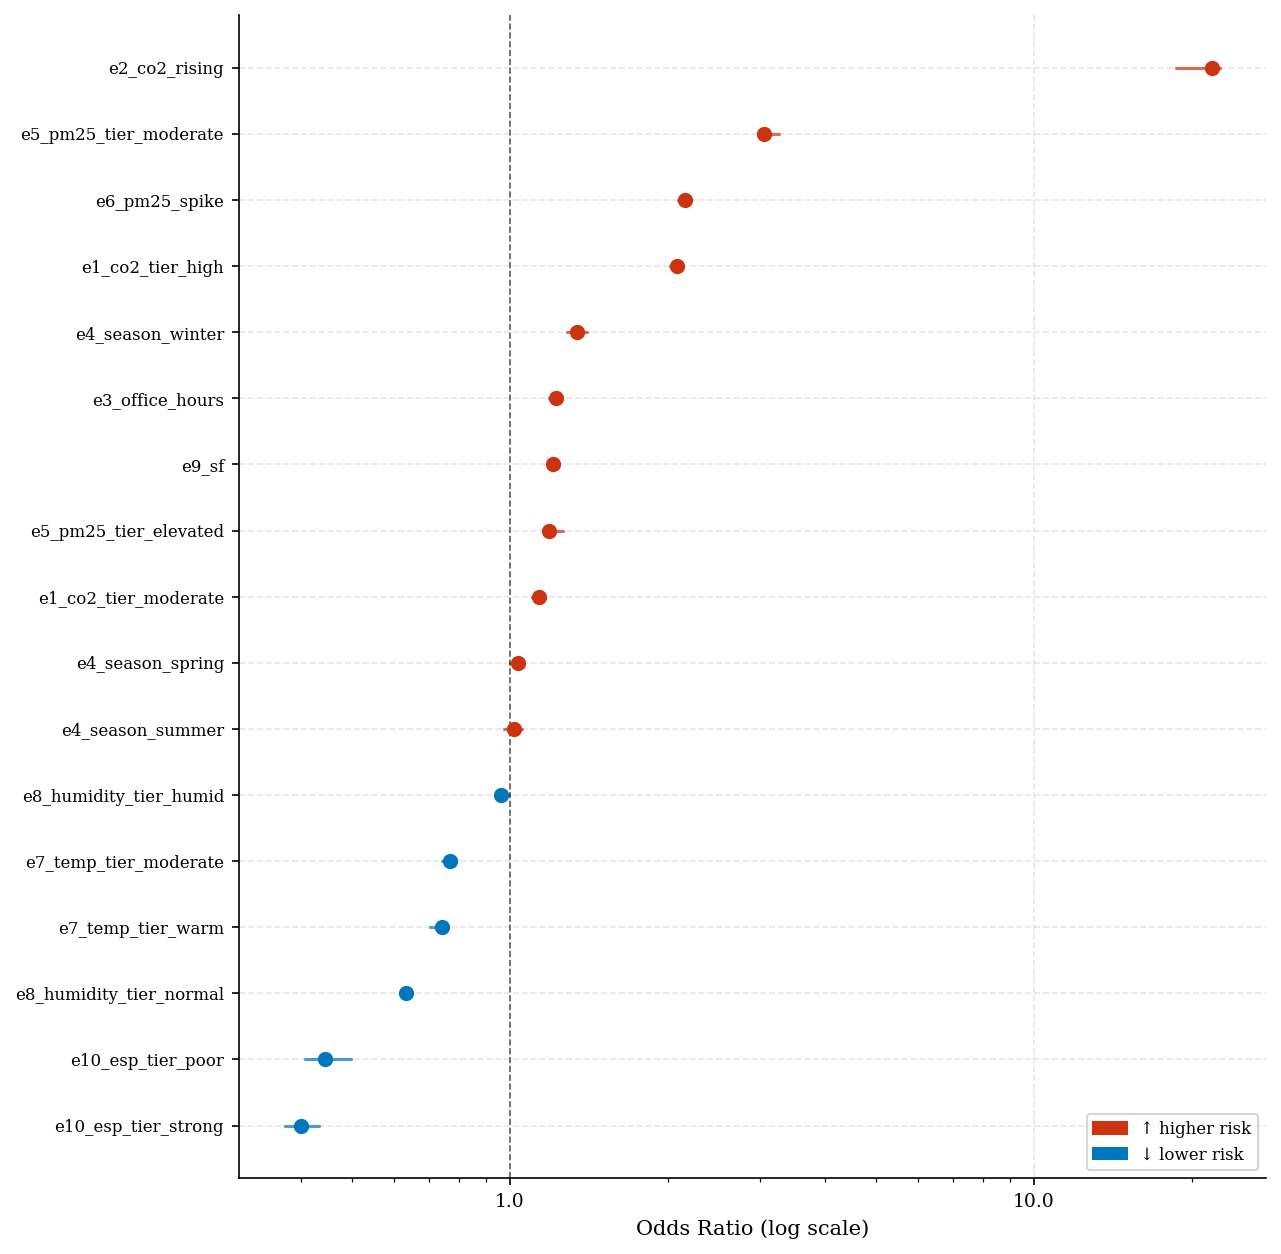

In [20]:
# Fig 03-I — Loss Risk Forest Plot (loss model only)
ev_loss_only = []
for feat in feat_names:
    if feat.startswith('device_id'): continue
    ev_loss_only.append({
        'predictor': feat,
        'OR_loss': float(odds_ratios.get(feat, 1.0)),
        'CI_lo': float(ci_loss.loc[feat, 'CI_lo']) if feat in ci_loss.index else 1.0,
        'CI_hi': float(ci_loss.loc[feat, 'CI_hi']) if feat in ci_loss.index else 1.0,
    })

ev_j = pd.DataFrame(ev_loss_only).sort_values('OR_loss', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(ev_j) * 0.38 + 2))

for i, row in ev_j.iterrows():
    color = C['red'] if row['OR_loss'] > 1 else C['blue']
    ax.plot([row['CI_lo'], row['CI_hi']], [i, i],
            color=color, lw=1.5, alpha=0.7, solid_capstyle='round')
    ax.scatter(row['OR_loss'], i, color=color, s=40, zorder=5)

ax.axvline(x=1.0, color='black', lw=0.8, ls='--', alpha=0.6)
ax.set_yticks(range(len(ev_j)))
ax.set_yticklabels(ev_j['predictor'], fontsize=8)
ax.set_xlabel('Odds Ratio (log scale)')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
# ax.set_title(f'Loss Risk OR with 95% CI  (AUC={auc_loss:.3f})\n'
#              'red = higher risk | blue = lower risk', fontsize=11, fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=C['red'], label='\u2191 higher risk'),
                   mpatches.Patch(color=C['blue'], label='\u2193 lower risk')],
          loc='lower right', fontsize=8)

fig.tight_layout()
fig.subplots_adjust(left=0.30)
save_fig(fig, '03_i_loss_risk_forest')


## 11 · Burst Loss Risk Model  *(§7.7 — RQ3)*

Same framework predicting burst loss: `y = 1[tx_loss >= 3]`

Burst-loss ORs are systematically larger than packet-loss ORs for the same
events — high-occupancy and high-SF conditions disproportionately increase burst severity.


In [21]:
print('=' * 60)
print('LOGISTIC REGRESSION — BURST RISK MODEL (§7.7)')
print('=' * 60)

df_link['burst_occurred'] = (df_link['tx_loss'] >= 3).astype(int)
y_burst = df_link['burst_occurred'].values

print(f'Fitting burst risk model ({N_BOOT} bootstrap samples) ...')
or_burst, ci_burst, auc_burst = fit_lr_bootstrap(X, y_burst)
print(f'  AUC (burst risk) = {auc_burst:.3f}')

print(f'\n{"Predictor":<40} {"OR_loss":>10} {"OR_burst":>10} {"Ratio":>8}')
print('-' * 72)
print('--- EVENT PREDICTORS ---')
for feat in odds_ratios.index:
    if feat.startswith('device_id'): continue
    or_l = odds_ratios[feat]
    or_b = or_burst[feat]
    ratio = or_b / or_l if or_l > 0 else 0
    marker = ' ←' if ratio > 1.5 else ''
    print(f'{feat:<40} {or_l:>10.4f} {or_b:>10.4f} {ratio:>7.2f}x{marker}')

print('\n--- DEVICE FIXED EFFECTS ---')
for feat in odds_ratios.index:
    if not feat.startswith('device_id'): continue
    or_l = odds_ratios[feat]
    or_b = or_burst[feat]
    ratio = or_b / or_l if or_l > 0 else 0
    print(f'{feat:<40} {or_l:>10.4f} {or_b:>10.4f} {ratio:>7.2f}x')

print('\nNote: ratio > 1.5x means the condition amplifies burst severity')
print('      beyond its effect on isolated packet loss')

LOGISTIC REGRESSION — BURST RISK MODEL (§7.7)
Fitting burst risk model (10 bootstrap samples) ...
  AUC (burst risk) = 0.760

Predictor                                   OR_loss   OR_burst    Ratio
------------------------------------------------------------------------
--- EVENT PREDICTORS ---
e2_co2_rising                               21.8317    52.2091    2.39x ←
e5_pm25_tier_moderate                        3.0539     7.4816    2.45x ←
e6_pm25_spike                                2.1616     1.7380    0.80x
e1_co2_tier_high                             2.0893     2.1148    1.01x
e4_season_winter                             1.3420     0.7596    0.57x
e3_office_hours                              1.2239     1.2420    1.01x
e9_sf                                        1.2075     1.0319    0.85x
e5_pm25_tier_elevated                        1.1890     1.2839    1.08x
e1_co2_tier_moderate                         1.1374     0.9471    0.83x
e4_season_spring                             1.0355 

Computing micro-granular burst size odds ratios (Sizes 0–9)...
  Saved: figures/03_j_loss_vs_detailed_burst_or


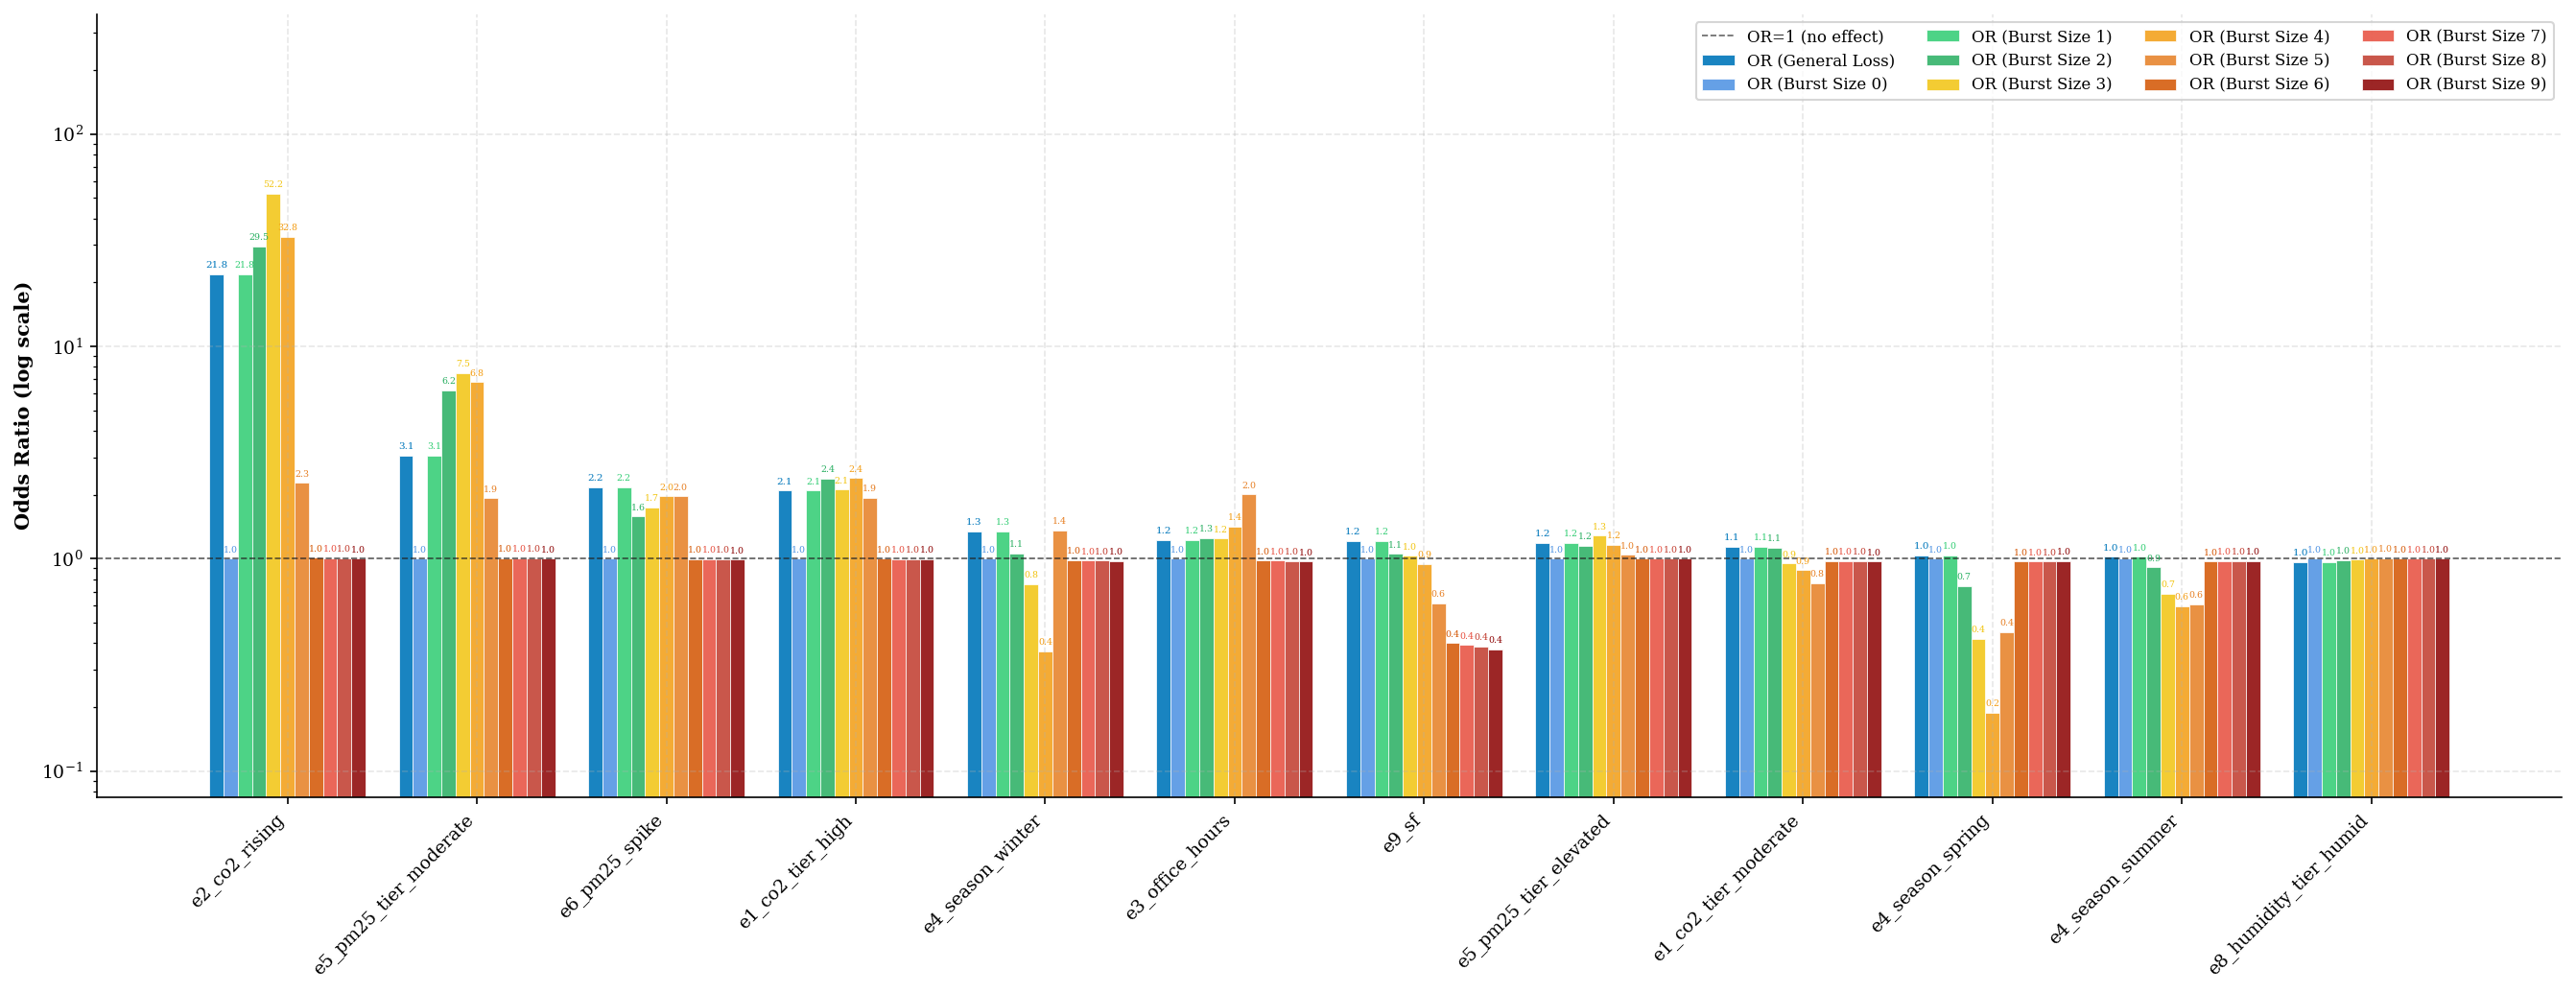

In [22]:
# Fig 03-J — Loss vs Detailed Burst Size OR comparison (top 12)
from sklearn.linear_model import LogisticRegression

print("Computing micro-granular burst size odds ratios (Sizes 0–9)...")
or_burst_sizes = {}
for size in range(10):
    if size == 0:
        # Size 0 represents perfect transmission / baseline reference condition
        or_burst_sizes[size] = {feat: 1.0 for feat in feat_names}
    else:
        # Fast single fit of logistic regression for cumulative burst severity: tx_loss >= size
        y_size = (df_link['tx_loss'] >= size).astype(int)
        if len(np.unique(y_size)) > 1:
            try:
                model = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0)
                model.fit(X, y_size)
                ors = np.exp(model.coef_[0])
                or_burst_sizes[size] = dict(zip(feat_names, ors))
            except Exception:
                or_burst_sizes[size] = {feat: 1.0 for feat in feat_names}
        else:
            or_burst_sizes[size] = {feat: 1.0 for feat in feat_names}

burst_sizes = list(range(10))  # 0 to 9 inclusive
ev_rows = []

for feat in feat_names:
    if feat.startswith('device_id'): continue

    row_dict = {
        'predictor': feat,
        'OR_loss': float(odds_ratios.get(feat, 1.0))
    }

    for size in burst_sizes:
        val = or_burst_sizes[size].get(feat, 1.0)
        row_dict[f'OR_burst_{size}'] = float(val)

    ev_rows.append(row_dict)

ev = pd.DataFrame(ev_rows)
ev_top = ev.sort_values('OR_loss', ascending=False).head(12).reset_index(drop=True)

x = np.arange(len(ev_top))
# 1 general loss bar + 10 individual burst size bars = 11 bars total per group
w = 0.075

fig, ax = plt.subplots(figsize=(18, 7))

# Plot General Loss baseline bar
ax.bar(x - 5 * w, ev_top['OR_loss'], w, color=C['blue'], alpha=0.9,
       label='OR (General Loss)', edgecolor='white', lw=0.4)

# 10 distinct colors matching your custom color environment context mapping from cool to hot
burst_colors = [
    '#4a90e2', '#2ecc71', '#27ae60', '#f1c40f', '#f39c12',
    '#e67e22', '#d35400', '#e74c3c', '#c0392b', '#8b0000'
]

for idx, size in enumerate(burst_sizes):
    ax.bar(x - (4 - idx) * w, ev_top[f'OR_burst_{size}'], w, color=burst_colors[idx],
           alpha=0.85, label=f'OR (Burst Size {size})', edgecolor='white', lw=0.4)

ax.axhline(y=1.0, color='black', lw=0.8, ls='--', alpha=0.6, label='OR=1 (no effect)')
ax.set_yscale('log')

# Micro-text layout for ultra-packed data columns
for i2, row in ev_top.iterrows():
    ax.text(i2 - 5 * w, row['OR_loss'] * 1.05, f'{row["OR_loss"]:.1f}', ha='center', va='bottom', fontsize=5, color=C['blue'])
    for idx, size in enumerate(burst_sizes):
        val = row[f'OR_burst_{size}']
        ax.text(i2 - (4 - idx) * w, val * 1.05, f'{val:.1f}', ha='center', va='bottom', fontsize=4.5, color=burst_colors[idx])

ax.set_xticks(x)
ax.set_xticklabels(ev_top['predictor'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Odds Ratio (log scale)', fontweight='bold')
# ax.set_title('Loss Risk vs Micro-Granular Burst Size Odds Ratios (Sizes 0–9) — Top 12 Predictors', fontsize=12, fontweight='bold')

# Compact matrix legend layout to keep it clean
ax.legend(fontsize=8, loc='upper right', ncol=4)

all_or_cols = ['OR_loss'] + [f'OR_burst_{s}' for s in burst_sizes]
ax.set_ylim(bottom=min(ev_top[all_or_cols].min()) * 0.4, top=max(ev_top[all_or_cols].max()) * 7)

fig.tight_layout()
save_fig(fig, '03_j_loss_vs_detailed_burst_or')

## 12 · Key Findings Summary  *(§7 summary)*

Thesis-ready statements for Chapter 7.


In [23]:
print('=' * 65)
print('KEY FINDINGS SUMMARY')
print('=' * 65)

# PDR values needed for Key Findings summary
lost_link = int(df_link['tx_loss'].sum())
pdr_link = len(df_link) / (len(df_link) + lost_link) * 100
total_app = int(df['fw_drop'].sum())
total_radio = int(df['tx_loss'].sum())
pdr_system = len(df) / (len(df) + total_app + total_radio) * 100
pdr_raw = len(df) / (len(df) + total_radio) * 100

# Per-device PDR_link spread — near-uniform PDR is the headline
# evidence for the collision-dominated loss hypothesis
device_pdrs = df_link.groupby('device_id').apply(
    lambda g: len(g) / (len(g) + int(g['tx_loss'].sum())) * 100
)
pdr_range = float(device_pdrs.max() - device_pdrs.min())

print(f"""
┌─ RQ1: Campaign-Wide Reliability ───────────────────────┐
  PDR_system (full pipeline)  : {pdr_system:.2f}%
  PDR_raw    (radio layer)    : {pdr_raw:.2f}%
  PDR_link   (env. losses)    : {pdr_link:.2f}%
  PDR range across 6 devices  : {pdr_range:.2f} pp  ← collision-dominated evidence
  Total intervals analysed    : {len(df_link):,}
└─────────────────────────────────────────────────────────┘
""")

print(f"""
┌─ RQ2: Event-Conditioned PDR ───────────────────────┐
  Top findings ranked by effect size r:

  {'Event':<6} {'Comparison':<35} {'Diff(pp)':>9} {'r':>8}
  {'-' * 62}""")

for _, row in results_df.head(6).iterrows():
    print(f"  {row['Event']:<6} {row['Comparison']:<35} {row['Diff_pp']:>+8.2f} {row['Effect_r']:>8.4f}")

widening = joint_results['high']['gap'] - joint_results['background']['gap']
print(f"""
  SF × CO₂ interaction (§7.6 — novel finding):
    Background CO₂ : gap = {joint_results['background']['gap']:.2f} pp
    High CO₂       : gap = {joint_results['high']['gap']:.2f} pp
    Widening        : {widening:+.2f} pp → SF×occupancy interaction confirmed
└─────────────────────────────────────────────────────────┘
""")

print(f"""
┌─ RQ3: Strongest Predictors (Logistic Regression) ───────────┐
  AUC = {auc_loss:.3f} (loss risk)  |  AUC = {auc_burst:.3f} (burst risk)

  {'Predictor':<35} {'OR (loss)':>10} {'OR (burst)':>12}
  {'-' * 60}""")

top_predictors = [
    'e2_co2_rising', 'e1_co2_tier_high',
    'e5_pm25_tier_elevated', 'e6_pm25_spike',
    'e9_sf',
]
for feat in top_predictors:
    if feat not in odds_ratios.index:
        continue
    or_l = odds_ratios.get(feat, float('nan'))
    or_b = or_burst.get(feat, float('nan'))
    print(f"  {feat:<35} {or_l:>10.3f} {or_b:>12.3f}")

print(f"""
  Device fixed effects (relative to ED0):
    ED5 OR = {odds_ratios.get('device_id_ED5', float('nan')):.3f} — lower loss risk → supports collision hypothesis
└─────────────────────────────────────────────────────────┘
""")


KEY FINDINGS SUMMARY

┌─ RQ1: Campaign-Wide Reliability ───────────────────────┐
  PDR_system (full pipeline)  : 83.77%
  PDR_raw    (radio layer)    : 91.04%
  PDR_link   (env. losses)    : 92.12%
  PDR range across 6 devices  : 3.01 pp  ← collision-dominated evidence
  Total intervals analysed    : 2,634,764
└─────────────────────────────────────────────────────────┘


┌─ RQ2: Event-Conditioned PDR ───────────────────────┐
  Top findings ranked by effect size r:

  Event  Comparison                           Diff(pp)        r
  --------------------------------------------------------------
  E2     CO2 rising vs stable                  -83.26  -0.2527
  E5     Elevated vs Clean PM2.5               -17.20  -0.1190
  E1     High CO2 vs Background                 -1.98  -0.0241
  E6     PM2.5 spike vs normal                  +1.47  -0.0227
  E9     SF12 vs SF7                            -5.69  -0.0187
  E10    Poor vs Strong ESP                     -3.21  -0.0142

  SF × CO₂ interaction

## 13 · Save Results


In [24]:
# save complete event results table
results_df.to_csv(DATA_DIR / '3_results.csv', index=False)

# save OR table — loss + burst + 95% CI (Table 7.8)
or_table = pd.DataFrame({
    'predictor': odds_ratios.index,
    'OR_loss': odds_ratios.values,
    'loss_CI_lo': [ci_loss.loc[f, 'CI_lo'] for f in odds_ratios.index],
    'loss_CI_hi': [ci_loss.loc[f, 'CI_hi'] for f in odds_ratios.index],
    'OR_burst': [or_burst[f] for f in odds_ratios.index],
    'burst_CI_lo': [ci_burst.loc[f, 'CI_lo'] for f in odds_ratios.index],
    'burst_CI_hi': [ci_burst.loc[f, 'CI_hi'] for f in odds_ratios.index],
})
or_table.to_csv(DATA_DIR / '3_odds_ratios.csv', index=False)

# save joint SF x CO2 interaction results (§7.6, novel finding)
joint_df = pd.DataFrame(joint_results).T
joint_df.index.name = 'co2_tier'
joint_df.to_csv(DATA_DIR / '3_joint_sf_co2.csv')

print(f'Saved: {DATA_DIR / "3_results.csv"}')
print(f'Saved: {DATA_DIR / "3_odds_ratios.csv"}')
print(f'Saved: {DATA_DIR / "3_joint_sf_co2.csv"}')
print(f'\nNotebook 03 complete.')


Saved: ..\data\3_results.csv
Saved: ..\data\3_odds_ratios.csv
Saved: ..\data\3_joint_sf_co2.csv

Notebook 03 complete.
